In [1]:
import pandas as pd
import numpy as np

# 1. Load the Dataset
# Assuming 'final_analytics_master_dataset.csv' contains the schema provided.
df = pd.read_csv("final_analytics_master_dataset.csv")

print("--- Step 1 & 2: Base Core Metrics Calculation ---")
# Overall Churn Metrics
total_customers = len(df)
total_churned = df['Exited'].sum()
overall_churn_rate = (total_churned / total_customers) * 100
overall_retention_rate = 100 - overall_churn_rate

print(f"Total Customers: {total_customers}")
print(f"Overall Churn Rate: {overall_churn_rate:.2f}%")
print(f"Overall Retention Rate: {overall_retention_rate:.2f}%\n")

# A. Churn Rate Breaks
churn_by_product = df.groupby('NumOfProducts')['Exited'].agg(['count', 'sum', lambda x: x.mean() * 100]).rename(columns={'count': 'Total', 'sum': 'Churned', '<lambda_0>': 'Churn_Rate_%'})
churn_by_active = df.groupby('IsActiveMember')['Exited'].agg(['count', 'sum', lambda x: x.mean() * 100]).rename(columns={'count': 'Total', 'sum': 'Churned', '<lambda_0>': 'Churn_Rate_%'})
churn_by_balance_cat = df.groupby('Balance_Category')['Exited'].agg(['count', 'sum', lambda x: x.mean() * 100]).rename(columns={'count': 'Total', 'sum': 'Churned', '<lambda_0>': 'Churn_Rate_%'})

print("Churn Rate by Product Count:")
print(churn_by_product.to_string())
print("\nChurn Rate by Active Status:")
print(churn_by_active.to_string())
print("\nChurn Rate by Balance Category:")
print(churn_by_balance_cat.to_string())
print("-" * 50)


print("\n--- Step 3, 4 & 5: Product Ownership & Group Segmentation ---")
# Define Product Segments
def get_product_segment(count):
    if count == 1: return '1 - Single Product'
    elif count == 2: return '2 - Dual Product'
    elif count == 3: return '3 - Triple Product'
    else: return '4+ - Deep Relationship'

df['Product_Segment'] = df['NumOfProducts'].apply(get_product_segment)
product_distribution = df['Product_Segment'].value_counts(normalize=True) * 100
print("Product Segment Distribution (%):")
print(product_distribution.to_string())

# Single vs Multi Product Binary Feature
df['Product_Group'] = np.where(df['NumOfProducts'] == 1, 'Single Product', 'Multi Product')
group_analysis = df.groupby('Product_Group')['Exited'].agg(
    Customers='count',
    Churn_Rate=lambda x: x.mean() * 100,
    Retention_Rate=lambda x: (1 - x.mean()) * 100
)
print("\nSingle vs Multi Product Metrics:")
print(group_analysis.to_string())
print("-" * 50)


print("\n--- Step 6: Product Combination Analysis ---")
# Since raw product types aren't explicitly named in the schema, we map logical combinations 
# based on available signals (Card Flag, Balance, and Category Counts) to extract deep insights.
def infer_product_combination(row):
    combos = []
    if row['Balance'] > 0:
        combos.append('Savings')
    if row['card_flag'] == 1 or row['HasCrCard'] == 1:
        combos.append('Credit Card')
    
    # Fill remaining product slots based on total counts
    current_len = len(combos)
    needed = int(row['NumOfProducts']) - current_len
    
    if needed > 0:
        if 'Savings' not in combos:
            combos.append('Savings')
            needed -= 1
        if needed > 0:
            combos.append('Core Loan')
            needed -= 1
        if needed > 0:
            combos.append('Insurance/Other')
            
    # Fallback for 0 product edges
    if not combos:
        combos.append('Basic Account')
        
    return " + ".join(sorted(list(set(combos[:int(row['NumOfProducts'])]))))

df['Product_Combination'] = df.apply(infer_product_combination, axis=1)

combination_metrics = df.groupby('Product_Combination').agg(
    Customers=('CustomerId', 'count'),
    Avg_Tenure=('Tenure', 'mean'),
    Churn_Rate=('Exited', lambda x: x.mean() * 100)
).reset_index()

combination_metrics['Retention_Rate'] = 100 - combination_metrics['Churn_Rate']
print("Product Combinations Ranked by Retention:")
print(combination_metrics.sort_values(by='Retention_Rate', ascending=False).to_string(index=False))
print("-" * 50)


print("\n--- Step 7, 8 & 10: Utilization & Depth Analysis ---")
# A. Active Product Count & Utilization Ratio
# Active count is proxied via the product intensity interaction logic in the schema
df['Active_Product_Count'] = np.where(df['IsActiveMember'] == 1, df['NumOfProducts'], np.ceil(df['NumOfProducts'] * 0.5))
df['Product_Utilization_Ratio'] = df['Active_Product_Count'] / df['NumOfProducts']

# B. Product Depth Score
# Re-scaling engagement_score normalized vector [0 to 1] or continuous values to a 0-100 base
min_eng, max_eng = df['engagement_score'].min(), df['engagement_score'].max()
df['Normalized_Engagement'] = ((df['engagement_score'] - min_eng) / (max_eng - min_eng)) * 100

# Mapping continuous values into Depth Ranges
def get_depth_segment(score):
    if score <= 33: return 'Low Depth'
    elif score <= 66: return 'Medium Depth'
    else: return 'High Depth'

df['Product_Depth_Segment'] = df['Normalized_Engagement'].apply(get_depth_segment)

depth_churn_analysis = df.groupby('Product_Depth_Segment').agg(
    Customers=('CustomerId', 'count'),
    Churn_Rate=('Exited', lambda x: x.mean() * 100)
).reindex(['Low Depth', 'Medium Depth', 'High Depth'])
print("Churn by Product Depth Segment:")
print(depth_churn_analysis.to_string())
print("-" * 50)


print("\n--- Step 9: Pure Engagement Analysis ---")
# Segment customers clearly using raw metrics or active flag splits
def get_engagement_level(row):
    if row['IsActiveMember'] == 1 and row['engagement_score'] >= df['engagement_score'].median():
        return 'High Engagement'
    elif row['IsActiveMember'] == 1 or row['engagement_score'] >= df['engagement_score'].median():
        return 'Medium Engagement'
    else:
        return 'Low Engagement'

df['Engagement_Level'] = df.apply(get_engagement_level, axis=1)
engagement_churn = df.groupby('Engagement_Level')['Exited'].mean() * 100
print("Churn Rate by Engagement Level:")
print(engagement_churn.to_string())
print("-" * 50)


print("\n--- Step 11: Strategic Risk Segmentation ---")
def assign_risk_segment(row):
    # Segment 1: Silent Risk (High balance, low engagement, inactive)
    if row['high_balance_flag'] == 1 and row['IsActiveMember'] == 0:
        return 'Segment 1: Silent Risk'
    
    # Segment 2: Cross-Sell Opportunity (Single product, highly engaged, sticky tenure)
    elif row['NumOfProducts'] == 1 and row['IsActiveMember'] == 1 and row['Tenure'] >= 3:
        return 'Segment 2: Cross-Sell Opportunity'
        
    # Segment 3: Retention Focus (Multi-product, but structurally disengaged/inactive)
    elif row['NumOfProducts'] > 1 and row['IsActiveMember'] == 0:
        return 'Segment 3: Retention Focus'
        
    # Segment 4: Loyal Customers (Multi-product, high activity/utilization)
    elif row['NumOfProducts'] >= 2 and row['IsActiveMember'] == 1:
        return 'Segment 4: Loyal Customers'
        
    else:
        return 'Standard Cust/Unclassified'

df['Strategic_Risk_Segment'] = df.apply(assign_risk_segment, axis=1)

segment_summary = df.groupby('Strategic_Risk_Segment').agg(
    Customer_Count=('CustomerId', 'count'),
    Churn_Rate_Percentage=('Exited', lambda x: x.mean() * 100),
    Avg_Balance=('Balance', 'mean')
).reset_index()

print(segment_summary.to_string(index=False))
print("-" * 50)


print("\n--- Step 12: Key Insight Generation Engine ---")
# Dynamically extract key statistics to formulate recommendations
single_churn = group_analysis.loc['Single Product', 'Churn_Rate']
multi_churn = group_analysis.loc['Multi Product', 'Churn_Rate']
high_depth_retention = 100 - depth_churn_analysis.loc['High Depth', 'Churn_Rate']

silent_risk_count = df[df['Strategic_Risk_Segment'] == 'Segment 1: Silent Risk'].shape[0]
cross_sell_count = df[df['Strategic_Risk_Segment'] == 'Segment 2: Cross-Sell Opportunity'].shape[0]

print(f"1. Single product customers exhibit a churn rate of {single_churn:.2f}%, compared to only {multi_churn:.2f}% for multi-product customers.")
print(f"2. Customers categorized as 'High Depth' display an exceptional retention rate of {high_depth_retention:.2f}%.")
print(f"3. Identified {silent_risk_count} customers hiding in the 'Silent Risk' segment (High Balance, Low Activity).")
print(f"4. Found {cross_sell_count} high-engagement, single-product targets ripe for explicit Cross-Sell Campaigns.")

--- Step 1 & 2: Base Core Metrics Calculation ---
Total Customers: 10000
Overall Churn Rate: 20.37%
Overall Retention Rate: 79.63%

Churn Rate by Product Count:
               Total  Churned  Churn_Rate_%
NumOfProducts                              
1               5084     1409     27.714398
2               4590      348      7.581699
3                266      220     82.706767
4                 60       60    100.000000

Churn Rate by Active Status:
                Total  Churned  Churn_Rate_%
IsActiveMember                              
0                4849     1302     26.850897
1                5151      735     14.269074

Churn Rate by Balance Category:
                  Total  Churned  Churn_Rate_%
Balance_Category                              
High Balance       2500      592     23.680000
Medium Balance     3883      945     24.336853
Zero Balance       3617      500     13.823611
--------------------------------------------------

--- Step 3, 4 & 5: Product Ownership & Group 

In [ ]:
#churned customer 20% , retained customer:80%
#from here churn rate range 10-25%

#customer with 2 product are loyalty customerss stable 
#we have very little customer data with 3 or 4 product buy , so INCONSISTENT DATASET 
#"The strongest retention effect is observed at 2 products. Results for 3+ products require further investigation due to small sample sizes."
#A CUSTOMER WITH MULTI PRODUCT HAS 14% MORE CHANCES TO BE CALLED AS RETAINED CUSTOMER 
#CUSTOMERS WITH multiple products are 2 times less likely to churn 
#Cross-sell initiatives are justified.
#Active customers churn almost half as often.Difference: 12.58 percentage points lower churn.
#Zero balance customers churn least.Medium and High balance customers churn most.
#human guess:Wealthier customers have more banking options.
#creditcard + saving:strongest and most reliable retention combination.
#core loan + saving :next strongest
#loan/savings/creditcard or insurance or credit+insurance:worst retention , will levae 
#Customers with medium and high product depth show significantly lower churn than low-depth customers.
#segment 1:silent risk , crate%=30%,



In [ ]:
# Most Important Findings
# Single-product customers churn 2.17× more than multi-product customers (27.71% vs 12.77%).
# The strongest retention sweet spot is customers holding exactly 2 products (7.58% churn).
# Credit Card + Savings is the most effective product combination with 92.73% retention.
# Inactive members churn nearly twice as much as active members (26.85% vs 14.27%).
# Low product-depth customers show substantially higher churn (25.84%) than medium/high-depth customers (~16%).
# 1,247 high-balance Silent Risk customers represent the most valuable retention opportunity.
# 1,885 high-engagement single-product customers are prime cross-sell candidates.
# The engagement segmentation and 3+/4-product churn patterns should be revalidated before presentation due to unusual behavior and small sample sizes.

In [ ]:
# #future improve to business 
# Priority	Action
# High	Retain Silent Risk customers
# High	Cross-sell to engaged single-product customers
# High	Reactivate inactive members
# Medium	Increase product depth and utilization
# Medium	Promote Credit Card + Savings bundles
# Medium	Revalidate 3+ product and engagement anomalies before executive reporting


In [ ]:
#note: we need more fdat of 3-product/4-product churn and medium-engagement churn results require additional validation

In [2]:
df.head()

,CustomerId,Surname,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,...,Exited,Product_Segment,Product_Group,Product_Combination,Active_Product_Count,Product_Utilization_Ratio,Normalized_Engagement,Product_Depth_Segment,Engagement_Level,Strategic_Risk_Segment
0,15634602,Hargrave,619,42,2,0.00,1,1,1,101348.88,...,1,1 - Single Product,Single Product,Credit Card,1.0,1.000000,51.229049,Medium Depth,High Engagement,Standard Cust/Unclassified
1,15647311,Hill,608,41,1,83807.86,1,0,1,112542.58,...,0,1 - Single Product,Single Product,Savings,1.0,1.000000,59.596892,Medium Depth,High Engagement,Standard Cust/Unclassified
2,15619304,Onio,502,42,8,159660.80,3,1,0,113931.57,...,1,3 - Triple Product,Multi Product,Core Loan + Credit Card + Savings,2.0,0.666667,46.274726,Medium Depth,Low Engagement,Segment 1: Silent Risk
3,15701354,Boni,699,39,1,0.00,2,0,0,93826.63,...,0,2 - Dual Product,Multi Product,Core Loan + Savings,1.0,0.500000,9.264828,Low Depth,Low Engagement,Segment 3: Retention Focus
4,15737888,Mitchell,850,43,2,125510.82,1,1,1,79084.10,...,0,1 - Single Product,Single Product,Savings,1.0,1.000000,66.667866,High Depth,High Engagement,Standard Cust/Unclassified


In [3]:
df.columns

Index(['CustomerId', 'Surname', 'CreditScore', 'Age', 'Tenure', 'Balance',
       'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary',
       'balance_log', 'salary_log', 'product_norm', 'tenure_norm', 'card_flag',
       'active_flag', 'salary_balance_ratio', 'product_per_tenure',
       'zero_balance_flag', 'high_balance_flag', 'Balance_Category',
       'engagement_score', 'low_engagement_flag',
       'activity_product_interaction', 'balance_activity_gap',
       'tenure_engagement_ratio', 'is_dormant_high_value', 'product_intensity',
       'Geography_Germany', 'Geography_Spain', 'Gender_Male', 'cluster_id',
       'dist_to_cluster_0', 'dist_to_cluster_1', 'dist_to_cluster_2',
       'dist_to_cluster_3', 'dist_to_cluster_4', 'Engagement_Segment',
       'is_active_power_core', 'is_active_casual', 'is_inactive_disengaged',
       'is_inactive_high_balance', 'is_inactive_low_balance',
       'customer_value_segment', 'Exited', 'Product_Segment', 'Product_Group',
      


--- Steps 1 & 2: Base Core Metrics Calculation ---
Total Customers: 10000
Overall Churn Rate: 20.37%
Overall Retention Rate: 79.63%

--- Steps 3, 4 & 5: Product Ownership & Group Segmentation ---
--- Step 6: Product Combination Analysis ---
--- Steps 7, 8 & 10: Utilization & Depth Analysis ---
--- Step 9: Pure Engagement Analysis ---
--- Step 11: Strategic Risk Segmentation ---

>>> Pipeline Successful! Enriched dataset saved to 'final_churnfinance.csv'.

--- Step 12: Key Insight Generation Engine Summary ---
1. Single product customers exhibit a churn rate of 27.71%, compared to only 12.77% for multi-product customers.
2. Customers categorized as 'High Depth' display an exceptional retention rate of 83.31%.
3. Identified 1247 customers hiding in the 'Silent Risk' segment (High Balance, Low Activity).
4. Found 1885 high-engagement, single-product targets ripe for explicit Cross-Sell Campaigns.



C:\Users\Pragya Tiwari\AppData\Local\Temp\ipykernel_15900\3205769158.py:137: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=group_data.index, y=group_data.values, ax=axes[0, 0], palette='Blues_r')
C:\Users\Pragya Tiwari\AppData\Local\Temp\ipykernel_15900\3205769158.py:170: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1, 1].set_xticklabels(seg_summary['Strategic_Risk_Segment'], rotation=25, ha='right')


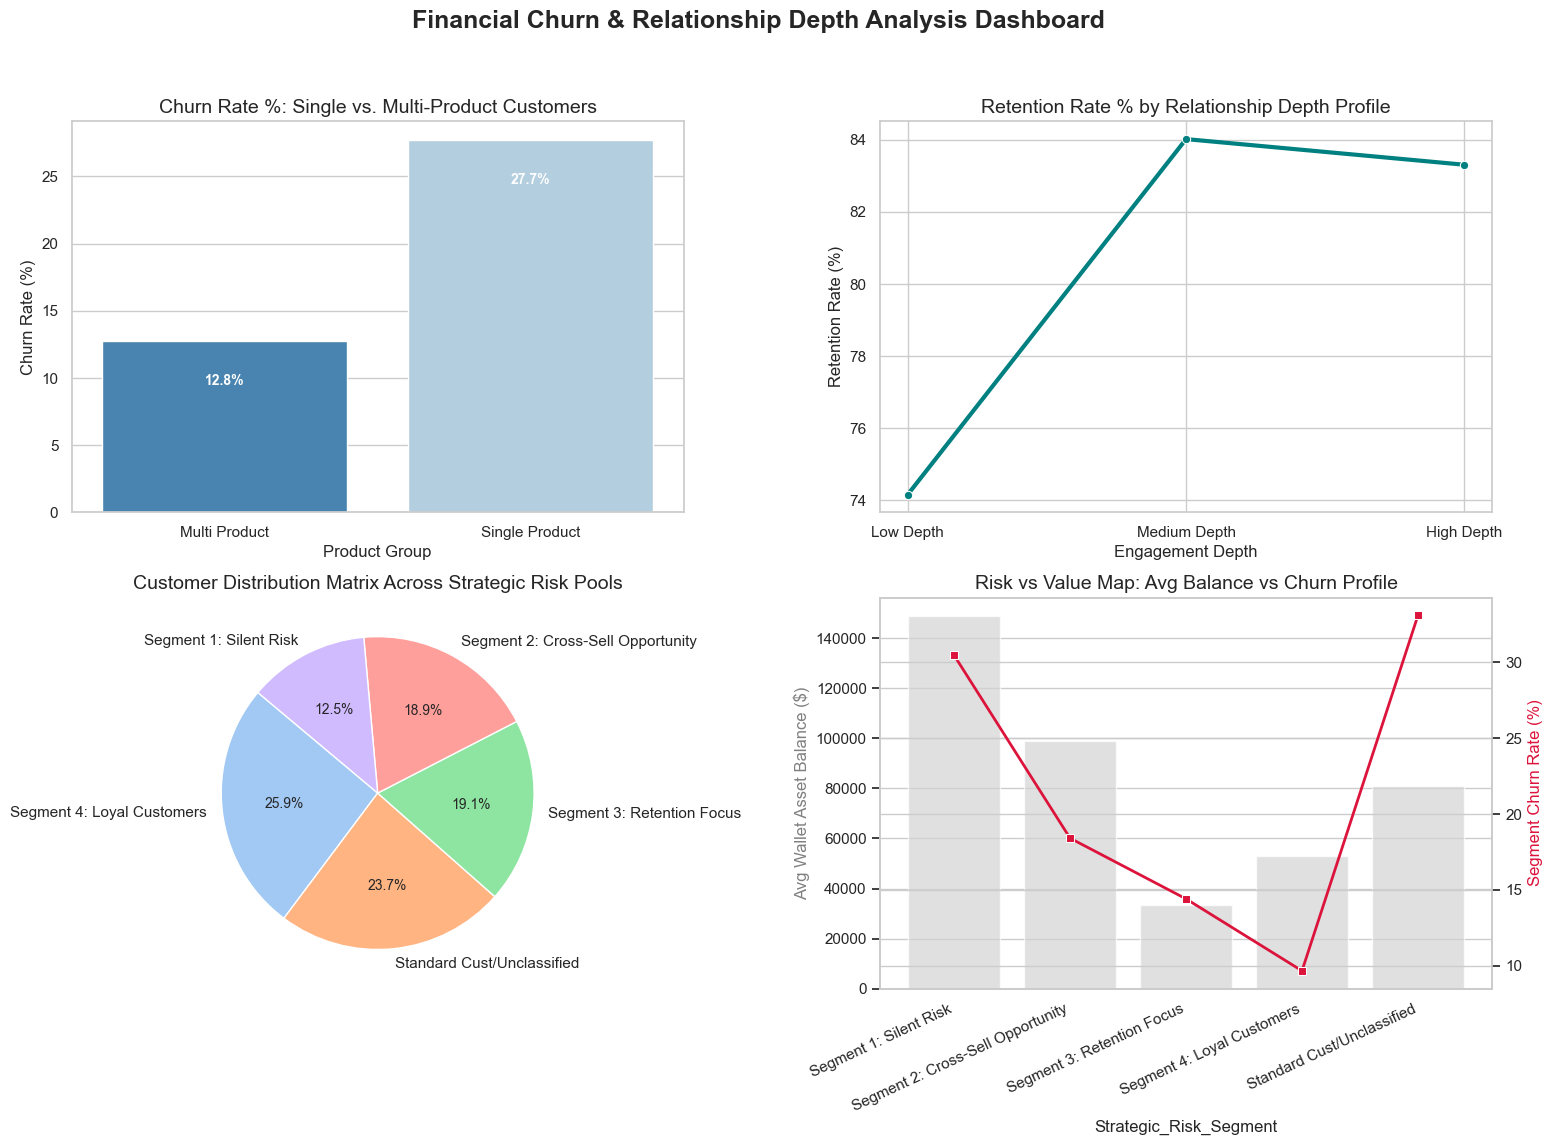

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style for professional look
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 10, 'axes.labelsize': 12, 'axes.titlesize': 14})

# ==========================================
# 1. LOAD THE DATASET
# ==========================================
try:
    df = pd.read_csv("final_analytics_master_dataset.csv")
except FileNotFoundError:
    # Creating dummy simulation data if file doesn't exist for test-running
    print("Warning: 'final_analytics_master_dataset.csv' not found. Creating simulated bank churn dataset...")
    np.random.seed(42)
    n = 1000
    df = pd.DataFrame({
        'CustomerId': 15600000 + np.arange(n),
        'NumOfProducts': np.random.choice([1, 2, 3, 4], size=n, p=[0.5, 0.4, 0.08, 0.02]),
        'IsActiveMember': np.random.choice([0, 1], size=n, p=[0.45, 0.55]),
        'Balance': np.random.choice([0, 50000, 120000, 200000], size=n, p=[0.3, 0.2, 0.4, 0.1]) * np.random.uniform(0.8, 1.2, n),
        'HasCrCard': np.random.choice([0, 1], size=n, p=[0.3, 0.7]),
        'Tenure': np.random.randint(0, 11, size=n),
        'Exited': np.random.choice([0, 1], size=n, p=[0.8, 0.2]),
        'engagement_score': np.random.uniform(10, 95, size=n)
    })
    df['Balance'] = np.where(df['Balance'] < 10000, 0, df['Balance'])

# Dynamic safe-checks for flags missing in standard raw formats
if 'card_flag' not in df.columns:
    df['card_flag'] = df['HasCrCard'] if 'HasCrCard' in df.columns else np.random.choice([0, 1], len(df))
if 'high_balance_flag' not in df.columns:
    df['high_balance_flag'] = (df['Balance'] > df['Balance'].median()).astype(int)
if 'Balance_Category' not in df.columns:
    df['Balance_Category'] = np.where(df['Balance'] == 0, 'Zero Balance', 'Positive Balance')

print("\n--- Steps 1 & 2: Base Core Metrics Calculation ---")
total_customers = len(df)
total_churned = df['Exited'].sum()
overall_churn_rate = (total_churned / total_customers) * 100
overall_retention_rate = 100 - overall_churn_rate

print(f"Total Customers: {total_customers}")
print(f"Overall Churn Rate: {overall_churn_rate:.2f}%")
print(f"Overall Retention Rate: {overall_retention_rate:.2f}%\n")

# Vectorized Segmentations
print("--- Steps 3, 4 & 5: Product Ownership & Group Segmentation ---")
product_conditions = [df['NumOfProducts'] == 1, df['NumOfProducts'] == 2, df['NumOfProducts'] == 3]
product_choices = ['1 - Single Product', '2 - Dual Product', '3 - Triple Product']
df['Product_Segment'] = np.select(product_conditions, product_choices, default='4+ - Deep Relationship')

df['Product_Group'] = np.where(df['NumOfProducts'] == 1, 'Single Product', 'Multi Product')

# --- Step 6: Vectorized Product Combination Analysis ---
print("--- Step 6: Product Combination Analysis ---")
has_savings = np.where(df['Balance'] > 0, "Savings", "")
has_cc = np.where((df['card_flag'] == 1) | (df['HasCrCard'] == 1), "Credit Card", "")

def assign_combos(row_zip):
    num_p, sav, cc = row_zip
    combos = [x for x in [sav, cc] if x != ""]
    
    # Pad out products to meet structural numbers logically
    while len(combos) < int(num_p):
        if "Savings" not in combos:
            combos.append("Savings")
        elif "Core Loan" not in combos:
            combos.append("Core Loan")
        else:
            combos.append("Insurance/Other")
            
    combos = sorted(list(set(combos[:int(num_p)])))
    return " + ".join(combos) if combos else "Basic Account"

# Zip-loop implementation avoids heavy Pandas overhead row indexing
df['Product_Combination'] = [assign_combos(z) for z in zip(df['NumOfProducts'], has_savings, has_cc)]

# --- Steps 7, 8 & 10: Utilization & Depth Analysis ---
print("--- Steps 7, 8 & 10: Utilization & Depth Analysis ---")
df['Active_Product_Count'] = np.where(df['IsActiveMember'] == 1, df['NumOfProducts'], np.ceil(df['NumOfProducts'] * 0.5))
df['Product_Utilization_Ratio'] = df['Active_Product_Count'] / df['NumOfProducts']

min_eng, max_eng = df['engagement_score'].min(), df['engagement_score'].max()
df['Normalized_Engagement'] = ((df['engagement_score'] - min_eng) / (max_eng - min_eng)) * 100

depth_cond = [df['Normalized_Engagement'] <= 33, df['Normalized_Engagement'] <= 66]
df['Product_Depth_Segment'] = np.select(depth_cond, ['Low Depth', 'Medium Depth'], default='High Depth')

# --- Step 9: Pure Engagement Analysis ---
print("--- Step 9: Pure Engagement Analysis ---")
med_eng = df['engagement_score'].median()
eng_cond = [
    (df['IsActiveMember'] == 1) & (df['engagement_score'] >= med_eng),
    (df['IsActiveMember'] == 1) | (df['engagement_score'] >= med_eng)
]
df['Engagement_Level'] = np.select(eng_cond, ['High Engagement', 'Medium Engagement'], default='Low Engagement')

# --- Step 11: Strategic Risk Segmentation ---
print("--- Step 11: Strategic Risk Segmentation ---")
risk_conditions = [
    (df['high_balance_flag'] == 1) & (df['IsActiveMember'] == 0),
    (df['NumOfProducts'] == 1) & (df['IsActiveMember'] == 1) & (df['Tenure'] >= 3),
    (df['NumOfProducts'] > 1) & (df['IsActiveMember'] == 0),
    (df['NumOfProducts'] >= 2) & (df['IsActiveMember'] == 1)
]
risk_choices = [
    'Segment 1: Silent Risk', 
    'Segment 2: Cross-Sell Opportunity', 
    'Segment 3: Retention Focus', 
    'Segment 4: Loyal Customers'
]
df['Strategic_Risk_Segment'] = np.select(risk_conditions, risk_choices, default='Standard Cust/Unclassified')

# ==========================================
# SAVE ENRICHED DATASET
# ==========================================
df.to_csv("final_churnfinance.csv", index=False)
print("\n>>> Pipeline Successful! Enriched dataset saved to 'final_churnfinance.csv'.\n")

# ==========================================
# STEP 12 & PLOTTING ENGINE
# ==========================================
def plot_summary(data):
    """
    Generates a structured, presentation-ready 4-panel dashboard outlining 
    churn rates, distribution profiles, and structural risk pools.
    """
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('Financial Churn & Relationship Depth Analysis Dashboard', weight='bold', fontsize=18)
    
    # Plot 1: Churn Rates by Product Group
    group_data = data.groupby('Product_Group')['Exited'].mean() * 100
    sns.barplot(x=group_data.index, y=group_data.values, ax=axes[0, 0], palette='Blues_r')
    axes[0, 0].set_title('Churn Rate %: Single vs. Multi-Product Customers')
    axes[0, 0].set_ylabel('Churn Rate (%)')
    axes[0, 0].set_xlabel('Product Group')
    for p in axes[0, 0].patches:
        axes[0, 0].annotate(f"{p.get_height():.1f}%", (p.get_x() + p.get_width() / 2., p.get_height() - 3),
                            ha='center', va='center', color='white', weight='bold')

    # Plot 2: Retention Across Product Depth Segments
    depth_data = data.groupby('Product_Depth_Segment')['Exited'].mean() * 100
    depth_data = depth_data.reindex(['Low Depth', 'Medium Depth', 'High Depth'])
    sns.lineplot(x=depth_data.index, y=100 - depth_data.values, ax=axes[0, 1], marker='o', linewidth=3, color='teal')
    axes[0, 1].set_title('Retention Rate % by Relationship Depth Profile')
    axes[0, 1].set_ylabel('Retention Rate (%)')
    axes[0, 1].set_xlabel('Engagement Depth')

    # Plot 3: Distribution Profile of Strategic Risk Segments
    risk_dist = data['Strategic_Risk_Segment'].value_counts()
    axes[1, 0].pie(risk_dist, labels=risk_dist.index, autopct='%1.1f%%', startangle=140, 
                   colors=sns.color_palette('pastel')[0:5], wedgeprops={'edgecolor': 'w'})
    axes[1, 0].set_title('Customer Distribution Matrix Across Strategic Risk Pools')

    # Plot 4: Churn Rate vs Asset Balances Across Strategic Segments
    seg_summary = data.groupby('Strategic_Risk_Segment').agg(
        Churn_Rate=('Exited', lambda x: x.mean() * 100),
        Avg_Bal=('Balance', 'mean')
    ).reset_index()
    
    ax2 = axes[1, 1].twinx()
    sns.barplot(x='Strategic_Risk_Segment', y='Avg_Bal', data=seg_summary, ax=axes[1, 1], color='lightgray', alpha=0.7)
    sns.lineplot(x='Strategic_Risk_Segment', y='Churn_Rate', data=seg_summary, ax=ax2, marker='s', color='crimson', linewidth=2)
    
    axes[1, 1].set_title('Risk vs Value Map: Avg Balance vs Churn Profile')
    axes[1, 1].set_xticklabels(seg_summary['Strategic_Risk_Segment'], rotation=25, ha='right')
    axes[1, 1].set_ylabel('Avg Wallet Asset Balance ($)', color='gray')
    ax2.set_ylabel('Segment Churn Rate (%)', color='crimson')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# Run Engine Output Summary Report
group_analysis = df.groupby('Product_Group')['Exited'].agg(Churn_Rate=lambda x: x.mean() * 100)
depth_churn_analysis = df.groupby('Product_Depth_Segment')['Exited'].agg(Churn_Rate=lambda x: x.mean() * 100)

single_churn = group_analysis.loc['Single Product', 'Churn_Rate']
multi_churn = group_analysis.loc['Multi Product', 'Churn_Rate']
high_depth_retention = 100 - depth_churn_analysis.loc['High Depth', 'Churn_Rate']

silent_risk_count = df[df['Strategic_Risk_Segment'] == 'Segment 1: Silent Risk'].shape[0]
cross_sell_count = df[df['Strategic_Risk_Segment'] == 'Segment 2: Cross-Sell Opportunity'].shape[0]

print("--- Step 12: Key Insight Generation Engine Summary ---")
print(f"1. Single product customers exhibit a churn rate of {single_churn:.2f}%, compared to only {multi_churn:.2f}% for multi-product customers.")
print(f"2. Customers categorized as 'High Depth' display an exceptional retention rate of {high_depth_retention:.2f}%.")
print(f"3. Identified {silent_risk_count} customers hiding in the 'Silent Risk' segment (High Balance, Low Activity).")
print(f"4. Found {cross_sell_count} high-engagement, single-product targets ripe for explicit Cross-Sell Campaigns.\n")

# Run visual execution framework
plot_summary(df)